<a href="https://colab.research.google.com/github/22f2000792/MLP-prac/blob/main/week8_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from PIL import Image
import os

In [2]:
path='/content/drive/MyDrive/Dataset/image_dataset'

In [11]:
def load_images(data_dir, target_size=(200, 200)):
  images = []
  labels = []

  class_names = os.listdir(data_dir)
  for class_name in class_names:
    class_dir = os.path.join(data_dir, class_name)
    for image_name in os.listdir(class_dir):
      image_path = os.path.join(class_dir, image_name)
      try:
        image = Image.open(image_path).resize(target_size).convert('L')
        image_array = np.array(image).flatten()/255.0
        # print (image_array.shape)

        # add images to image list along with class label in label list.
        images.append(image_array)
        labels.append(class_name)
      except Exception as e:
        print(f"Error loading image {image_path}: {e}")
        continue

  return np.array(images), np.array(labels)

In [12]:
images, labels = load_images(path)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1136: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [18]:
np.sum(labels=='without_mask')

np.int64(3828)

Encode the labels using LabelEncoder such that without_mask will be mapped to 1 and with_mask will be mapped to 0.

* Split the dataset with 20% datapoints for test set and keep the random_state to be 0.

* Train a LogisticRegression with

random_state=0, max_iter=500, tol=0.001, C=10

This is going to take some time. Hold tight!

How many false positive data points are there on test dataset? Consider "without_mask" to be positive class.

In [22]:
labels

array(['without_mask', 'without_mask', 'without_mask', ..., 'with_mask',
       'with_mask', 'with_mask'], dtype='<U12')

In [24]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
labels=le.fit_transform(labels)

In [25]:
labels

array([1, 1, 1, ..., 0, 0, 0])

In [29]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(images,labels,random_state=0,test_size=0.2)
print(X_train.shape,y_train.shape)

(6042, 40000) (6042,)


In [33]:
from sklearn.linear_model import LogisticRegression
logr=LogisticRegression(max_iter=500,tol=0.001,C=10,random_state=0)
logr.fit(X_train,y_train)

LogisticRegression(C=10, max_iter=500, random_state=0, tol=0.001)

In [34]:
logr_pre=logr.predict(X_test)

In [40]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
confusion_matrix(y_test,logr_pre)


array([[459, 286],
       [237, 529]])

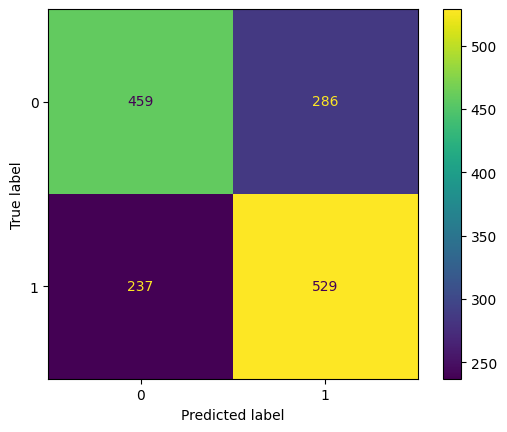

In [42]:
ConfusionMatrixDisplay(confusion_matrix(y_test,logr_pre)).plot()
plt.show()